In [1]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
t=2    Caps=[9, 9, 10, 10]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[8, 8, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[7, 5, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[5, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[3, 3, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 2, 3]
True
t=7    Caps=[2, -1, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [5]:
from dqn_agent import DQNAgent
from standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork)

In [6]:
reward_history = agent.train(num_episodes=1000)

Episode   50/1000  Reward:   406.00  Avg(50):   422.14  ε: 0.778
Episode  100/1000  Reward:   393.00  Avg(50):   439.34  ε: 0.606
Episode  150/1000  Reward:   483.00  Avg(50):   465.40  ε: 0.471
Episode  200/1000  Reward:   621.00  Avg(50):   510.54  ε: 0.367
Episode  250/1000  Reward:   776.00  Avg(50):   535.26  ε: 0.286
Episode  300/1000  Reward:   563.00  Avg(50):   593.26  ε: 0.222
Episode  350/1000  Reward:   714.00  Avg(50):   625.66  ε: 0.173
Episode  400/1000  Reward:   703.00  Avg(50):   651.62  ε: 0.135
Episode  450/1000  Reward:   667.00  Avg(50):   677.34  ε: 0.105
Episode  500/1000  Reward:   667.00  Avg(50):   706.00  ε: 0.100
Episode  550/1000  Reward:   837.00  Avg(50):   706.60  ε: 0.100
Episode  600/1000  Reward:   657.00  Avg(50):   720.56  ε: 0.100
Episode  650/1000  Reward:   657.00  Avg(50):   734.38  ε: 0.100
Episode  700/1000  Reward:   768.00  Avg(50):   724.60  ε: 0.100
Episode  750/1000  Reward:   837.00  Avg(50):   750.90  ε: 0.100
Episode  800/1000  Reward

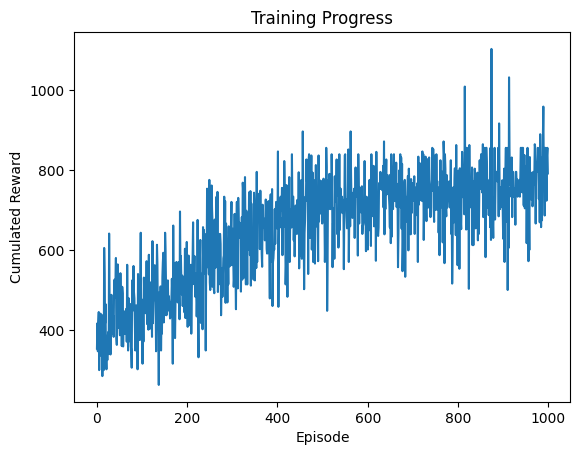

In [7]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.show()

## Standard DQN scheint nicht (gut) zu funktionieren 
Negative kummulierte Rewards, der Agent kann nur durch Ausprobieren lernen welche Actions unzulässig sind, braucht lange und ist noisy!

In [8]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

In [9]:
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np

# Callback der die Rewards speichert
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self) -> bool:
        self._current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True

# Training mit bestehender env
callback = RewardCallback()
model = DQN("MlpPolicy", env, verbose=1, exploration_fraction=0.4, exploration_final_eps=0.05)
model.learn(total_timesteps=200_000, log_interval=4, callback=callback)

# Plot
plt.plot(callback.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress (SB3 DQN)")
plt.show()

ModuleNotFoundError: No module named 'stable_baselines3'